In [3]:
## Dependencies
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(r"C:\Users\colin\Downloads\RGI2000-v7.0-G-01_alaska-attributes.csv")

print(df.columns)                 

Index(['rgi_id', 'o1region', 'o2region', 'glims_id', 'anlys_id', 'subm_id',
       'src_date', 'cenlon', 'cenlat', 'utm_zone', 'area_km2', 'primeclass',
       'conn_lvl', 'surge_type', 'term_type', 'glac_name', 'is_rgi6',
       'termlon', 'termlat', 'zmin_m', 'zmax_m', 'zmed_m', 'zmean_m',
       'slope_deg', 'aspect_deg', 'aspect_sec', 'dem_source', 'lmax_m'],
      dtype='str')


In [48]:
chosenData = df.loc[:, ['cenlon','cenlat','area_km2','zmean_m','slope_deg','aspect_deg','lmax_m']]
print(chosenData)

           cenlon     cenlat  area_km2     zmean_m  slope_deg  aspect_deg  \
0     -155.909404  67.413726  0.239199  1553.94030  17.606613  342.330469   
1     -155.879114  67.419232  0.104641  1330.91500  19.846369  345.367012   
2     -155.530786  67.431484  0.216605  1437.23520  23.690063   13.467490   
3     -155.501948  67.430514  0.252649  1249.06620  12.782562   42.854332   
4     -155.478173  67.432873  0.474716  1273.78340  17.148510  299.058193   
...           ...        ...       ...         ...        ...         ...   
27504 -127.943494  58.381563  0.190275  1956.88500  30.104969   24.649687   
27505 -127.994907  58.374932  0.230076  2041.02940  28.225796   85.414560   
27506 -128.003487  58.380406  0.187298  1907.25850  26.389137  348.349361   
27507 -128.146532  58.381816  0.152301  2120.08740  25.529028   70.835080   
27508 -131.229844  55.685681  0.124837   750.69824  19.760427    6.034411   

       lmax_m  
0         725  
1         484  
2        1099  
3         6

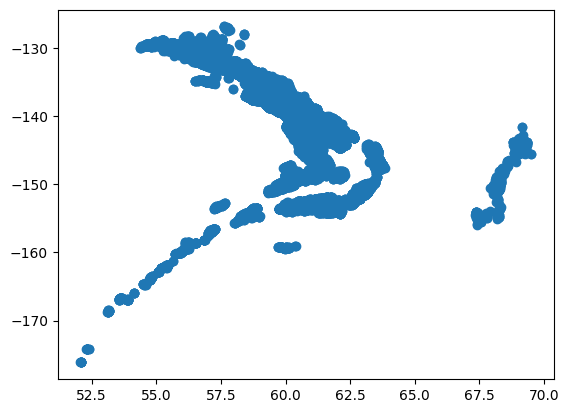

In [ ]:
#plotting by location,slopes,lmax,zmean_m
plt.scatter(chosenData['cenlat'],chosenData['cenlon'])

(array([  57.,  860., 4479., 8684., 7971., 3557., 1312.,  466.,  104.,
          19.]),
 array([ 0.87078226,  6.60776833, 12.34475441, 18.08174048, 23.81872656,
        29.55571263, 35.2926987 , 41.02968478, 46.76667085, 52.50365693,
        58.240643  ]),
 <BarContainer object of 10 artists>)

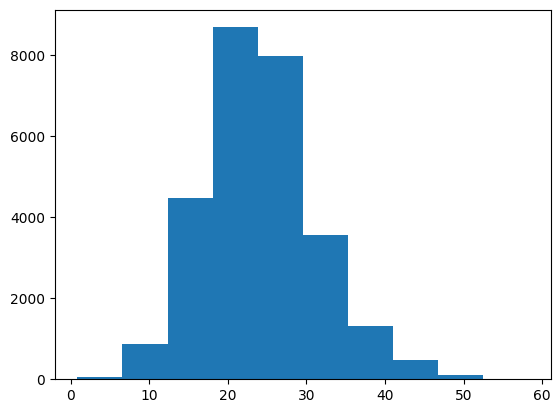

In [87]:
plt.hist(chosenData['slope_deg'])

(array([2.731e+04, 1.400e+02, 3.800e+01, 1.400e+01, 4.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([8.400000e+01, 2.056880e+04, 4.105360e+04, 6.153840e+04,
        8.202320e+04, 1.025080e+05, 1.229928e+05, 1.434776e+05,
        1.639624e+05, 1.844472e+05, 2.049320e+05]),
 <BarContainer object of 10 artists>)

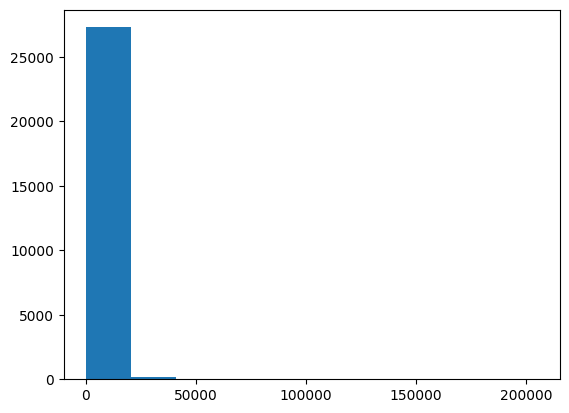

In [88]:
plt.hist(chosenData['lmax_m'])

(array([4.2500e+02, 5.8380e+03, 1.3185e+04, 6.3610e+03, 1.3800e+03,
        1.8600e+02, 8.8000e+01, 2.9000e+01, 1.3000e+01, 4.0000e+00]),
 array([  93.097435 ,  652.4631915, 1211.828948 , 1771.1947045,
        2330.560461 , 2889.9262175, 3449.291974 , 4008.6577305,
        4568.023487 , 5127.3892435, 5686.755    ]),
 <BarContainer object of 10 artists>)

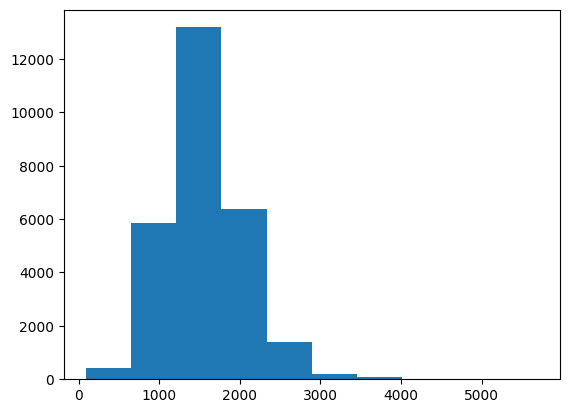

In [89]:
plt.hist(chosenData['zmean_m'])

In [51]:
corrMatrix = chosenData.corr()
corrMatrix.style.background_gradient(cmap='coolwarm')

,cenlon,cenlat,area_km2,zmean_m,slope_deg,aspect_deg,lmax_m
cenlon,1.000000,-0.539581,-0.000631,0.138500,0.021095,-0.092966,-0.007697
cenlat,-0.539581,1.000000,0.008230,0.285072,0.062618,0.024593,0.010378
area_km2,-0.000631,0.008230,1.000000,-0.003735,-0.119344,-0.004918,0.797626
zmean_m,0.138500,0.285072,-0.003735,1.000000,0.274637,-0.060017,-0.008803
slope_deg,0.021095,0.062618,-0.119344,0.274637,1.000000,-0.004214,-0.292909
aspect_deg,-0.092966,0.024593,-0.004918,-0.060017,-0.004214,1.000000,-0.011386
lmax_m,-0.007697,0.010378,0.797626,-0.008803,-0.292909,-0.011386,1.000000


In [ ]:
cleanData = chosenData.dropna()


In [98]:
U, S, Vt = np.linalg.svd(cleanData, full_matrices=False)

# Project data onto principal components (scores)
pca_result = U * S

# Calculate explained variance ratio
explained_variance = (S ** 2) / (len(cleanData) - 1)
explained_variance_ratio = explained_variance / explained_variance.sum()

# What proportion is variance is explained by each PC?
print("Explained variance:")
for i, var in enumerate(explained_variance_ratio):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Explained variance:
  PC1: 0.8942 (89.42%)
  PC2: 0.1048 (10.48%)
  PC3: 0.0009 (0.09%)
  PC4: 0.0001 (0.01%)
  PC5: 0.0000 (0.00%)
  PC6: 0.0000 (0.00%)
  PC7: 0.0000 (0.00%)


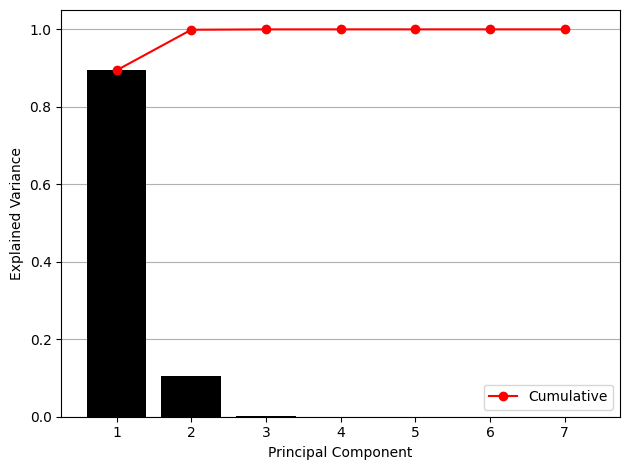

In [65]:
fig, ax = plt.subplots()
ax.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 
       color='black')
ax.plot(range(1, len(explained_variance_ratio)+1), np.cumsum(explained_variance_ratio), 
        'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
ax.set_xticks(range(1, len(explained_variance_ratio)+1))
ax.legend()
ax.grid(True, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [66]:
pca_result[:, 0] *= -1
pca_result[:, 1] *= -1

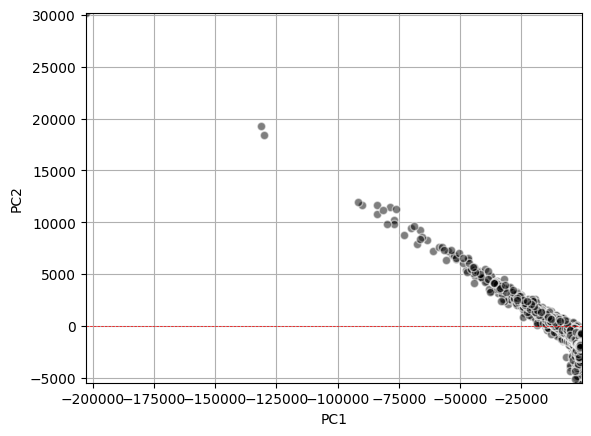

In [ ]:
fig, ax = plt.subplots()
ax.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, color='k', edgecolors='w')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.axhline(y=0, color='r', linestyle='--', linewidth=0.5)
ax.axvline(x=0, color='r', linestyle='--', linewidth=0.5)
ax.set_xlim(pca_result[:, 0].min(), pca_result[:, 0].max())
ax.set_ylim(pca_result[:, 1].min(), pca_result[:, 1].max())
ax.grid(True)
ax.set_axisbelow(True)
plt.show()



In [95]:
cols = cleanData.columns.tolist()  

In [97]:
loadings = pd.DataFrame(Vt.T, index=cols, columns=[f'PC{i+1}' for i in range(len(cols))])
print("\nLoadings for PC1 and PC2:")
print(loadings[['PC1', 'PC2']])


Loadings for PC1 and PC2:
                 PC1       PC2
cenlon      0.013736  0.079034
cenlat     -0.005809 -0.033643
area_km2   -0.007002  0.007204
zmean_m    -0.152680 -0.978665
slope_deg  -0.001920 -0.014454
aspect_deg -0.017731 -0.103656
lmax_m     -0.987977  0.154375


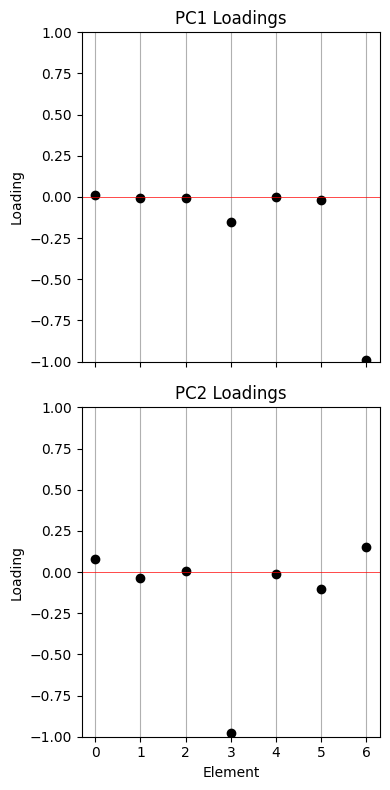

In [102]:
fig, axes = plt.subplots(2, 1, figsize=(4, 8), sharex=True)
x = np.arange(len(cols))

# PC1 loadings
ax1 = axes[0]
ax1.scatter(x, loadings['PC1'], color='black')
ax1.set_ylabel('Loading')
ax1.axhline(y=0, color='r', linestyle='-', linewidth=0.5)
ax1.set_ylim(-1, 1)
ax1.grid(True, axis='x')
ax1.set_axisbelow(True)
ax1.set_title('PC1 Loadings')

# PC2 loadings
ax2 = axes[1]
ax2.scatter(x, loadings['PC2'], color='black')
ax2.set_ylabel('Loading')
ax2.set_xlabel('Element')
ax2.set_xticks(x)
#ax2.set_xticklabels(latex_cols, rotation=45, ha='right')
ax2.axhline(y=0, color='r', linestyle='-', linewidth=0.5)
ax2.set_ylim(-1, 1)
ax2.grid(True, axis='x')
ax2.set_axisbelow(True)
ax2.set_title('PC2 Loadings')

plt.tight_layout()
plt.show()